In [1]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [2]:
fpaths = glob.glob("AnalysisZipFramework/submission/analysis_output/*.root")
print(f"found {len(fpaths)} files")

found 555 files


In [3]:
wissals_2022_runs = [8025, 8115, 8120, 8124, 8155, 8157, 8175, 8179, 8182, 8190, 8191, 8248, 8252, 8266, 8269, 8290, 8294, 8301, 8320, 8326, 8327, 8330, 8331, 8332, 8333, 8336, 8728, 8731, 8733, 8736, 8775, 8777, 8798, 8799, 8834, 8841, 8848, 8850, 8906, 8908, 8913, 8915, 8916, 8917, 8930, 8933, 8934, 8943, 8945, 8947, 8948, 8949, 8950, 8970, 8972, 8975, 8977, 8981, 8985, 8987, 9058, 9060, 9069, 9072, 9073, 9092, 9094, 9148, 9166, 9181, 9183, 9188]
wissals_2023_runs = [10604, 10605, 10615, 10694, 10695, 10699, 10700, 10701, 10729, 10732, 10733, 10738, 10775, 10792, 10794, 10796, 10829, 10847, 10849, 10857, 10859, 10881, 10921, 10928, 10955, 10956, 11041, 11070, 11081, 11082, 11086, 11088, 11089, 11093, 11096, 11098, 11127, 11156, 11208, 11211, 11212, 11213, 11243, 11523, 11527, 11528, 11583, 11584, 11585, 11586, 11589, 11590, 11595, 11597, 11613, 11700, 11703]
wissals_2024_noCaloNu_runs = [14743, 14758, 14760, 14767, 14769, 14771, 14777, 14797, 14799, 14804, 14809, 14810, 14906, 14954, 14971, 14972, 14974, 14975, 14977, 14980, 14981, 14985, 15007, 15015, 15016, 15024, 15025, 15031, 15032, 15034, 15050, 15051, 15052, 15055, 15059, 15269, 15270, 15287, 15290, 15387, 15388, 15390, 15391, 15394, 15398, 15415, 15422, 15425, 15429, 15432, 15434, 15438, 15439, 15445, 15446, 15683, 15685, 15687, 15751, 15754, 15755, 15758, 15762, 15763, 15766, 15784, 15785, 15786, 15787, 15789, 15790, 15814, 15818, 15820, 16800, 16929, 16930, 16931, 16934, 16937, 16938, 16940, 16941, 16943, 16974, 17018, 17023, 17095, 17102, 17147, 17199, 17230]
wissals_2024_CaloNu_runs = [15838, 15839, 15844, 15874, 15877, 15878, 15883, 15884, 15903, 15909, 15912, 15913, 15915, 15917, 15918, 15919, 15945, 15946, 15948, 15949, 15951, 15953, 15956, 15957, 15961, 15963, 15967, 15977, 15996, 15998, 16000, 16001, 16018, 16022, 16023, 16028, 16042, 16043, 16057, 16064, 16065, 16068, 16072, 16075, 16076, 16077, 16096, 16098, 16099, 16103, 16393, 16396, 16400, 16403, 16405, 16517, 16531, 16533, 16542, 16558, 16581, 16628, 16635, 16650, 16653, 16658, 16660, 16661, 16663, 16667, 16685, 16696, 16697, 16699, 16715, 16731, 16732, 16798, 16802, 16805, 16848, 16853, 16916, 16923]

good_runs = wissals_2022_runs + wissals_2023_runs + wissals_2024_noCaloNu_runs + wissals_2024_CaloNu_runs

In [4]:
print(f"Total number of good runs: {len(good_runs)}")

Total number of good runs: 305


In [5]:
def get_cutflow_and_yields_for_run_range(files, run_start, run_end, mass=1.1):
    cutflow_dict = {}
    run_yields = {}

    total_lumi = 0
    for fpath in tqdm.tqdm(files):

        run = int(os.path.basename(fpath).split("/")[-1].split(".")[0])
        if run not in good_runs: continue
        
        if run_start > run or run > run_end:
            continue

        with uproot.open(fpath) as f:
            tree = f["cutflow"]
            lumi = f["meta"].arrays(library="pd")["lumi"][0]
            df = tree.arrays(library="pd")

            run = int(os.path.basename(fpath).split("/")[-1].split(".")[0])
            if run not in good_runs: continue

            if run_start <= run <= run_end:
                total_lumi += lumi[0] / 1000 # /pb -> /fb
                for idx, row in df.iterrows():
                    cut = row["cut_name"]
                    all = row["all"]
                    passed = row["passed"]
            
                    if cut not in cutflow_dict:
                        cutflow_dict[cut] = {"all": 0, "passed": 0}
            
                    cutflow_dict[cut]["all"] += all
                    cutflow_dict[cut]["passed"] += passed
                    cutflow_dict[cut]["efficiency"] = cutflow_dict[cut]["passed"] / cutflow_dict[cut]["all"] if cutflow_dict[cut]["all"] > 0 else 0
                    cutflow_dict[cut]["cumulative_efficiency"] = cutflow_dict[cut]["passed"] / cutflow_dict[list(cutflow_dict.keys())[0]]["all"] if cutflow_dict[list(cutflow_dict.keys())[0]]["all"] > 0 else 0
                    cutflow_dict[cut]["efficiency_error"] = np.sqrt(cutflow_dict[cut]["efficiency"] * (1 - cutflow_dict[cut]["efficiency"]) / cutflow_dict[cut]["all"]) if cutflow_dict[cut]["all"] > 0 else 0


                final_yield = np.amin(df["passed"])
                run_yields[int(run)] = final_yield
                
    cutflow = pd.DataFrame.from_dict(cutflow_dict, orient="index")
    cutflow["rate [events/fb/tonne]"] = cutflow["passed"] / (total_lumi * mass) if total_lumi > 0 else 0
    cutflow = cutflow.sort_values(by='passed', ascending=False)
            
    return cutflow, run_yields

In [6]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

In [7]:
cutflow_F222, yields_F222 = get_cutflow_and_yields_for_run_range(fpaths, *runs_F222)
cutflow_F223, yields_F223 = get_cutflow_and_yields_for_run_range(fpaths, *runs_F223)
cutflow_F231, yields_F231 = get_cutflow_and_yields_for_run_range(fpaths, *runs_F231)
cutflow_F232, yields_F232 = get_cutflow_and_yields_for_run_range(fpaths, *runs_F232)
cutflow_F241, yields_F241 = get_cutflow_and_yields_for_run_range(fpaths, *runs_F241)
cutflow_tungsten, yields_tungsten = get_cutflow_and_yields_for_run_range(fpaths, *runs_tungsten)
cutflow_F242, yields_F242 = get_cutflow_and_yields_for_run_range(fpaths, *runs_F242)
cutflow_caloNu, yields_caloNu = get_cutflow_and_yields_for_run_range(fpaths, *runs_caloNu, mass=0.68)
cutflow_F243, yields_F243 = get_cutflow_and_yields_for_run_range(fpaths, *runs_F243)

  0%|          | 0/555 [00:00<?, ?it/s]

100%|██████████| 555/555 [00:03<00:00, 155.85it/s]


In [8]:
print("Cutflow for F222:")
display(cutflow_F222)
print("\n")
print("Cutflow for F223:")
display(cutflow_F223)
print("\n")
print("Cutflow for F231:")
display(cutflow_F231)
print("\n")
print("Cutflow for F232:")
display(cutflow_F232)
print("\n")
print("Cutflow for F241:")
display(cutflow_F241)
print("\n")
print("Cutflow for Tungsten:")
display(cutflow_tungsten)
print("\n")
print("Cutflow for F242:")
display(cutflow_F242)
print("\n")
print("Cutflow for CaloNu:")
display(cutflow_caloNu)
print("\n")
print("Cutflow for F243:")
display(cutflow_F243)

Cutflow for F222:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Colliding,64698251,64490570,0.996790,9.967900e-01,7.032467e-06,7.306479e+06
Trigger,64490570,64490517,0.999999,9.967892e-01,1.128864e-07,7.306473e+06
Good times,64490517,64490517,1.000000,9.967892e-01,0.000000e+00,7.306473e+06
Excluded times,64490517,64489115,0.999978,9.967675e-01,5.805952e-07,7.306314e+06
Sanity cut to remove events with missing aux data,64489115,64489115,1.000000,9.967675e-01,0.000000e+00,7.306314e+06
VetoNu0 reduced charge < 30 pC,64489115,1585944,0.024592,2.451293e-02,1.928637e-05,1.796800e+05
VetoNu1 reduced charge < 30 pC,1585944,1538738,0.970235,2.378330e-02,1.349426e-04,1.743318e+05
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),1538738,1536490,0.998539,2.374856e-02,3.079045e-05,1.740771e+05
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),1536490,1536486,0.999997,2.374849e-02,1.301666e-06,1.740766e+05
CaloNu status cleaning,1536486,1536486,1.000000,2.374849e-02,0.000000e+00,1.740766e+05




Cutflow for F223:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Colliding,178527092,178446058,0.999546,9.995461e-01,1.594156e-06,6.944844e+06
Trigger,178446058,178445848,0.999999,9.995449e-01,8.120868e-08,6.944836e+06
Good times,178445848,178445848,1.000000,9.995449e-01,0.000000e+00,6.944836e+06
Excluded times,178445848,178445317,0.999997,9.995419e-01,1.291339e-07,6.944815e+06
Sanity cut to remove events with missing aux data,178445317,178445317,1.000000,9.995419e-01,0.000000e+00,6.944815e+06
VetoNu0 reduced charge < 30 pC,178445317,3628049,0.020331,2.032212e-02,1.056504e-05,1.411980e+05
VetoNu1 reduced charge < 30 pC,3628049,3514403,0.968676,1.968554e-02,9.145199e-05,1.367751e+05
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),3514403,3507686,0.998089,1.964792e-02,2.329811e-05,1.365137e+05
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),3507686,3507672,0.999996,1.964784e-02,1.066700e-06,1.365132e+05
CaloNu status cleaning,3507672,3507672,1.000000,1.964784e-02,0.000000e+00,1.365132e+05




Cutflow for F231:


...

,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Colliding,140538633,139658553,0.993738,9.937378e-01,6.654283e-06,1.502540e+07
Trigger,139658553,139658442,0.999999,9.937370e-01,7.543863e-08,1.502539e+07
Good times,139658442,139658442,1.000000,9.937370e-01,0.000000e+00,1.502539e+07
Excluded times,139658442,138806459,0.993900,9.876747e-01,6.589000e-06,1.493373e+07
Sanity cut to remove events with missing aux data,138806459,138806459,1.000000,9.876747e-01,0.000000e+00,1.493373e+07
VetoNu0 reduced charge < 30 pC,138806459,2630123,0.018948,1.871459e-02,1.157242e-05,2.829662e+05
VetoNu1 reduced charge < 30 pC,2630123,2561696,0.973983,1.822770e-02,9.815523e-05,2.756044e+05
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),2561696,2551155,0.995885,1.815270e-02,3.999613e-05,2.744703e+05
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),2551155,2551144,0.999996,1.815262e-02,1.300046e-06,2.744692e+05
CaloNu status cleaning,2551144,2551144,1.000000,1.815262e-02,0.000000e+00,2.744692e+05




Cutflow for CaloNu:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Colliding,972055435,967678584,0.995497,9.954973e-01,2.147385e-06,2.448434e+07
Trigger,967678584,967676789,0.999998,9.954955e-01,4.378251e-08,2.448430e+07
Good times,967676789,967676789,1.000000,9.954955e-01,0.000000e+00,2.448430e+07
Excluded times,967676789,967324758,0.999636,9.951333e-01,6.130291e-07,2.447539e+07
Sanity cut to remove events with missing aux data,967324758,967324758,1.000000,9.951333e-01,0.000000e+00,2.447539e+07
VetoNu0 reduced charge < 30 pC,967324758,17877847,0.018482,1.839180e-02,4.330465e-06,4.523479e+05
VetoNu1 reduced charge < 30 pC,17877847,17446851,0.975892,1.794841e-02,3.627624e-05,4.414427e+05
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),17446851,17374528,0.995855,1.787401e-02,1.538222e-05,4.396128e+05
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),17374528,17374466,0.999996,1.787395e-02,4.531918e-07,4.396112e+05
CaloNu status cleaning,17374466,16941612,0.975087,1.742865e-02,3.739219e-05,4.286591e+05




Cutflow for F243:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Colliding,176954731,176214937,0.995819,9.958193e-01,4.850466e-06,1.500317e+07
Trigger,176214937,176214889,1.000000,9.958190e-01,3.931677e-08,1.500317e+07
Good times,176214889,176214889,1.000000,9.958190e-01,0.000000e+00,1.500317e+07
Excluded times,176214889,176214889,1.000000,9.958190e-01,0.000000e+00,1.500317e+07
Sanity cut to remove events with missing aux data,176214889,176214889,1.000000,9.958190e-01,0.000000e+00,1.500317e+07
VetoNu0 reduced charge < 30 pC,176214889,3322525,0.018855,1.877613e-02,1.024609e-05,2.828842e+05
VetoNu1 reduced charge < 30 pC,3322525,3241431,0.975593,1.831785e-02,8.465651e-05,2.759797e+05
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),3241431,3227526,0.995710,1.823927e-02,3.630072e-05,2.747958e+05
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),3227526,3227510,0.999995,1.823918e-02,1.239336e-06,2.747945e+05
CaloNu status cleaning,3227510,3227510,1.000000,1.823918e-02,0.000000e+00,2.747945e+05


In [9]:
def wrap_math_text(s, caption="My table"):
    s = s.replace(r"\begin{table}", "")
    s = s.replace(r"\end{table}", "")
    s = s.replace(r"<", r"$<$").replace(r">", r"$>$").replace("=", r"$=$").replace("+", r"$+$").replace("-", r"$-$").replace("*", r"$*$").replace("/", r"$/$").replace("<=", r"$\leq$").replace(">=", r"$\geq$").replace("!=", r"$\neq$")
    s = rf"""
\begin{{table}}
\centering
\caption{{{caption}}}
\begin{{adjustbox}}{{max width=\textwidth}}
{s}
\end{{adjustbox}}
\end{{table}}
"""
    return s

In [21]:
with open("cutflows_all_periods.tex", 'w') as f:

    longtable = False
    float_format = "{:0.2g}".format
    colums = ["passed", "efficiency", "cumulative_efficiency", "rate [events/fb/tonne]"]

    f.write(r"\documentclass{article}" + "\n")
    f.write(r"\usepackage{graphicx}" + "\n")
    f.write(r"\usepackage{booktabs}" + "\n")
    f.write(r"\usepackage{longtable}" + "\n")
    f.write(r"\usepackage{adjustbox}" + "\n")
    f.write(r"\begin{document}" + "\n")
    t = wrap_math_text(cutflow_F222.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for F222")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_F223.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for F223")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_F231.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for F231")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_F232.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for F232")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_F241.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for F241")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_tungsten.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for tungsten")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_F242.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for F242")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_caloNu.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for caloNu")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_F243.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for F243")
    f.write(t + "\n")
    f.write(r"\end{document}" + "\n") 


In [22]:
# with open("cutflows_all_periods.tex", 'w') as f:
#     # \documentclass{article}
#     # \usepackage{graphicx} % Required for inserting images
#     # \usepackage{booktabs}
#     # \begin{document}
#     longtable = False
#     f.write(r"\documentclass{article}" + "\n")
#     f.write(r"\usepackage{graphicx}" + "\n")
#     f.write(r"\usepackage{booktabs}" + "\n")
#     f.write(r"\usepackage{longtable}" + "\n")
#     f.wr
#     f.write(r"\begin{document}" + "\n")
#     t = wrap_math_text(cutflow_F222.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for F222", label="tab:cutflow_F222", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_F223.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for F223", label="tab:cutflow_F223", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_F231.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for F231", label="tab:cutflow_F231", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_F232.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for F232", label="tab:cutflow_F232", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_F241.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for F241", label="tab:cutflow_F241", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_tungsten.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for Tungsten", label="tab:cutflow_tungsten", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_F242.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for F242", label="tab:cutflow_F242", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_caloNu.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for CaloNu", label="tab:cutflow_caloNu", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_F243.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for F243", label="tab:cutflow_F243", longtable=longtable))
#     f.write(t + "\n")
#     f.write(r"\end{document}" + "\n") 


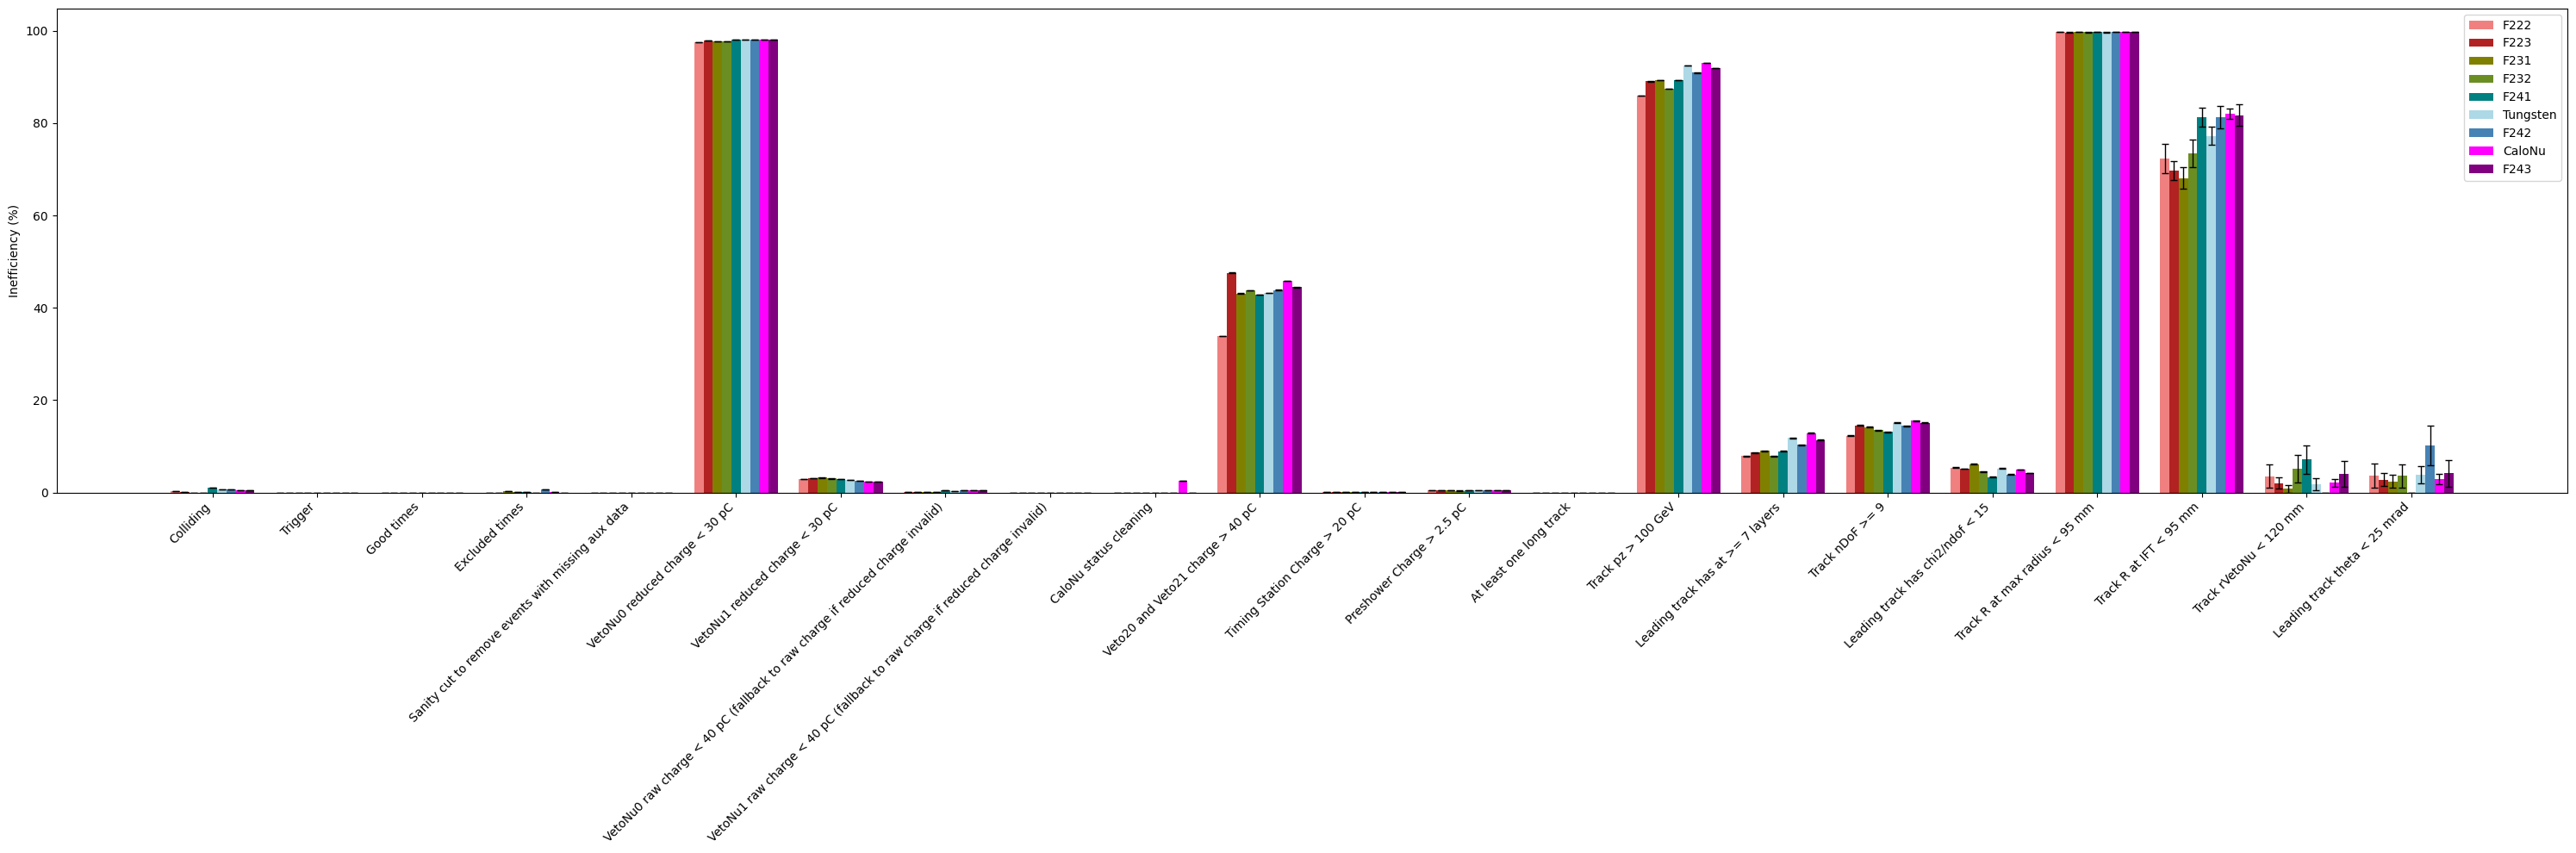

In [23]:
dfs = [cutflow_F222, cutflow_F223, cutflow_F231, cutflow_F232, cutflow_F241, cutflow_tungsten, cutflow_F242, cutflow_caloNu, cutflow_F243]
labels = ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"]
colours = ["lightcoral", "firebrick", "olive", "olivedrab", "teal", "lightblue", "steelblue", "magenta", "purple"]

fig, ax = plt.subplots(figsize=(30, 10))

n = len(dfs)
x = np.arange(len(dfs[0]))
total_width = 0.8           # Total width occupied by all bars
bar_width = total_width / n

for i, (df, label) in enumerate(zip(dfs, labels)):
    offset = (i - (n - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        100 - df["efficiency"]*100,
        width=bar_width,
        label=label,
        color=colours[i]
    )
    ax.errorbar(
        x + offset,
        100 - df["efficiency"]*100,
        yerr=df["efficiency_error"]*100,
        fmt='none',
        ecolor='black',
        capsize=3,
        elinewidth=1,
        label=None
    )

ax.set_xticks(x)
ax.set_xticklabels(dfs[0].index, rotation=45, ha="right")
ax.legend()
ax.set_ylabel("Inefficiency (%)")

plt.tight_layout()
plt.savefig("cutflow_inefficiency_comparison.png", dpi=300)
plt.show()

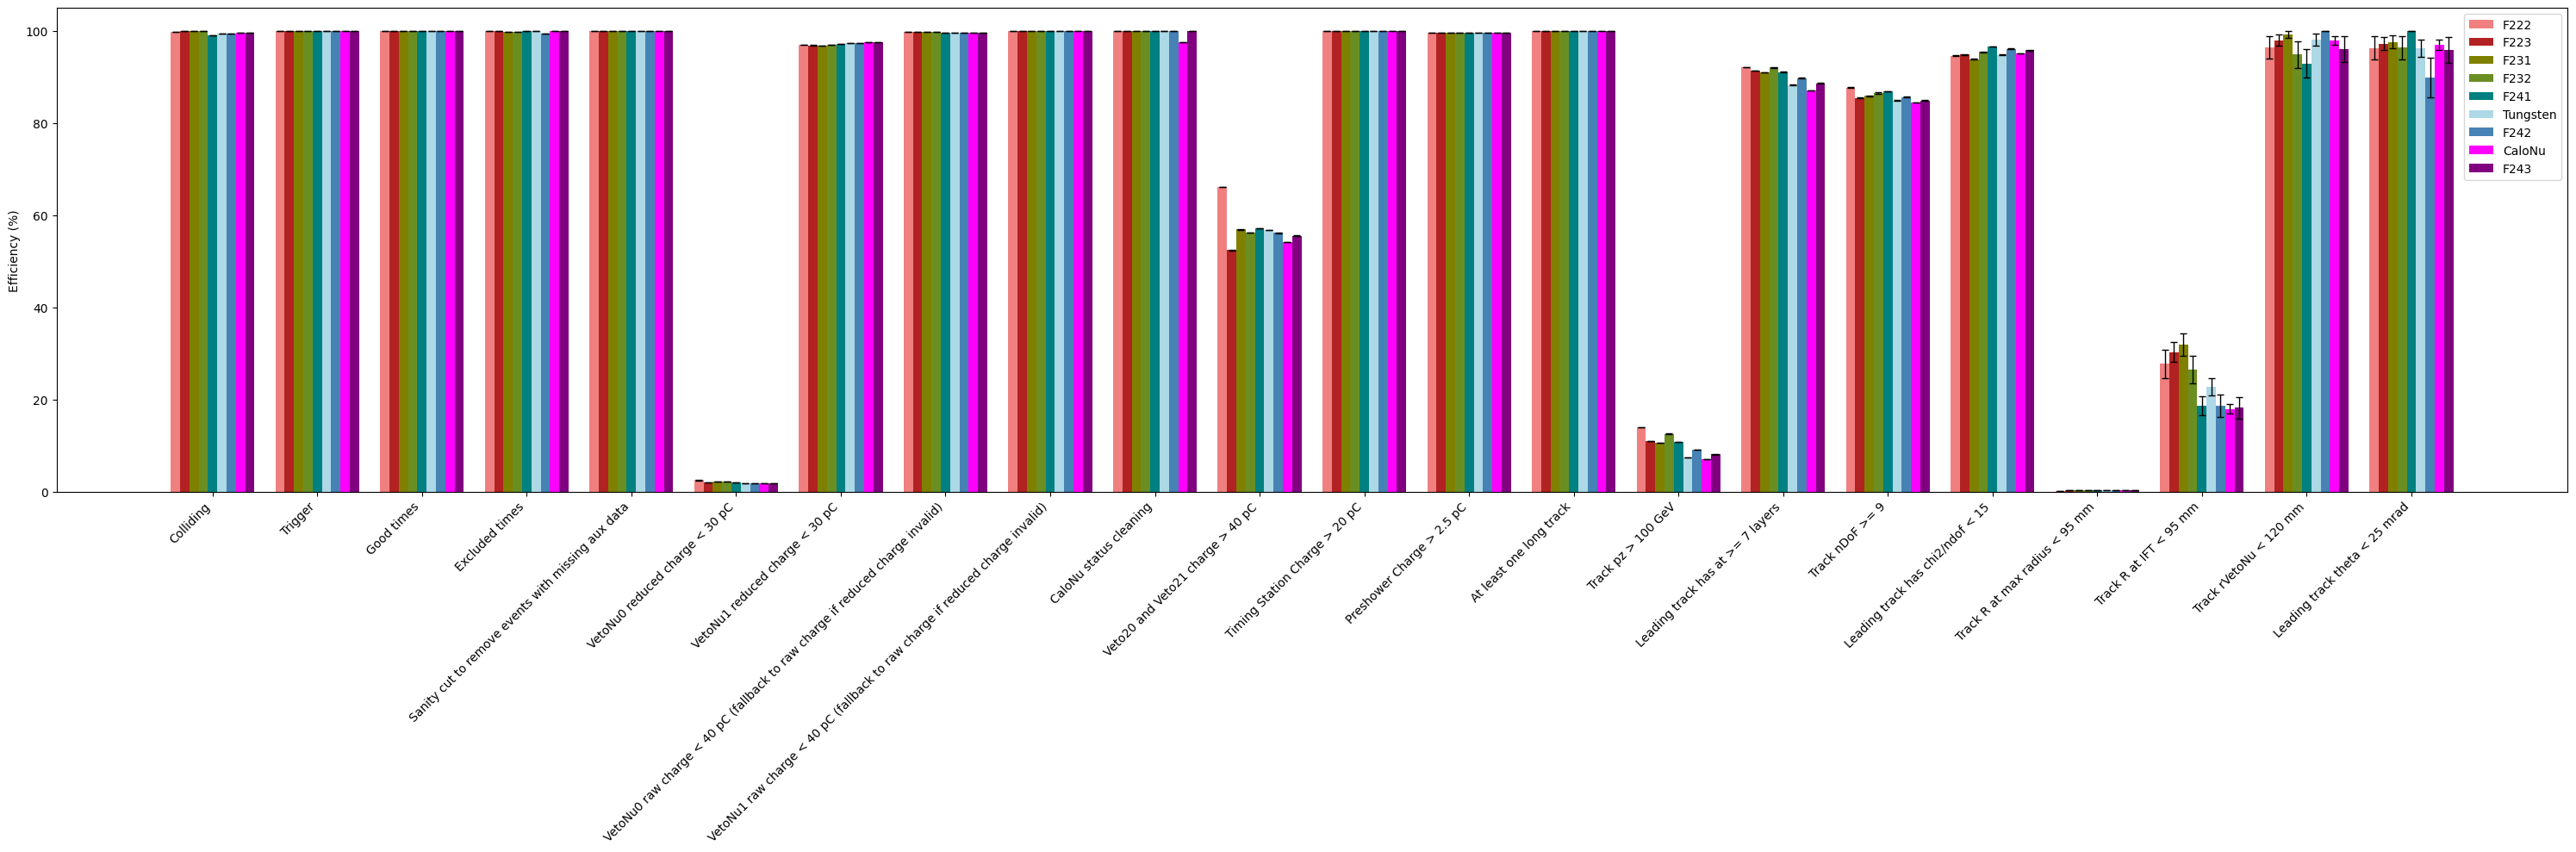

In [24]:
dfs = [cutflow_F222, cutflow_F223, cutflow_F231, cutflow_F232, cutflow_F241, cutflow_tungsten, cutflow_F242, cutflow_caloNu, cutflow_F243]
labels = ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"]
fig, ax = plt.subplots(figsize=(30, 10))

n = len(dfs)
x = np.arange(len(dfs[0]))
total_width = 0.8           # Total width occupied by all bars
bar_width = total_width / n

for i, (df, label) in enumerate(zip(dfs, labels)):
    offset = (i - (n - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        df["efficiency"]*100,
        width=bar_width,
        label=label,
        color=colours[i]
    )
    ax.errorbar(
        x + offset,
        df["efficiency"]*100,
        yerr=df["efficiency_error"]*100,
        fmt='none',
        ecolor='black',
        capsize=3,
        elinewidth=1,
        label=None
    )

ax.set_xticks(x)
ax.set_xticklabels(dfs[0].index, rotation=45, ha="right")
ax.legend()
ax.set_ylabel("Efficiency (%)")
# ax.set_yscale("log")

plt.tight_layout()
plt.savefig("cutflow_efficiency_comparison.png", dpi=300)
plt.show()

In [25]:
data = uproot.open("/home/ppd/bewilson/work/nuAnalysis/AnalysisZipFramework/submission/analysis_output/17023.root")
print(data.keys())
evt_idpass = data["eventID_pass"].arrays(library="pd")

['nt;1', 'meta;1', 'cutflow;1', 'eventID_pass;2']


In [26]:
display(evt_idpass)

,passed_Colliding,passed_Trigger,passed_Good_times,passed_Excluded_times,passed_Sanity_cut_to_remove_events_with_missing_aux_data,passed_VetoNu0_reduced_charge_lt_30_pC,passed_VetoNu1_reduced_charge_lt_30_pC,passed_VetoNu0_raw_charge_lt_40_pC_fallback_to_raw_charge_if_reduced_charge_invalid,passed_VetoNu1_raw_charge_lt_40_pC_fallback_to_raw_charge_if_reduced_charge_invalid,passed_CaloNu_status_cleaning,...,passed_Track_pz_gt_100_GeV,passed_Leading_track_has_at_geq_7_layers,passed_Track_nDoF_geq_9,passed_Leading_track_has_chi2_ndof_lt_15,passed_Track_R_at_max_radius_lt_95_mm,passed_Track_R_at_IFT_lt_95_mm,passed_Track_rVetoNu_lt_120_mm,passed_Leading_track_theta_lt_25_mrad,run,eventID
0,True,True,True,True,True,False,False,True,True,True,...,True,True,True,True,True,True,True,True,17023,811565
1,True,True,True,True,True,False,False,True,True,True,...,False,True,True,True,False,False,False,True,17023,811568
2,True,True,True,True,True,False,False,True,True,True,...,False,True,True,True,True,False,True,True,17023,811571
3,True,True,True,True,True,False,False,True,True,True,...,True,True,True,True,False,False,True,True,17023,811580
4,True,True,True,True,True,False,False,True,True,True,...,True,True,True,True,False,False,False,True,17023,811594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14301648,True,True,True,True,True,False,False,True,True,True,...,True,True,False,True,True,True,True,True,17023,92437830
14301649,True,True,True,True,True,False,False,True,True,True,...,False,True,True,True,False,False,False,True,17023,92437832
14301650,False,False,True,True,True,True,True,True,True,True,...,False,False,False,False,True,False,False,True,17023,92437834
14301651,True,True,True,True,True,False,False,True,True,True,...,True,True,True,True,False,True,True,True,17023,92437844


In [27]:
def get_pass_fail_counts_for_run_range(files, run_start, run_end):
    pass_fail_counts = {}

    for fpath in tqdm.tqdm(files):

        run = int(os.path.basename(fpath).split("/")[-1].split(".")[0])
        if run not in good_runs: continue
        
        if run_start > run or run > run_end:
            continue

        with uproot.open(fpath) as f:
            tree = f["eventID_pass"]
            df = tree.arrays(library="pd")

            run = int(os.path.basename(fpath).split("/")[-1].split(".")[0])
            if run not in good_runs: continue

            if run_start <= run <= run_end:
                for key in df.columns:

                    if "passed" not in key.lower(): continue
                    
                    if key not in pass_fail_counts:
                        pass_fail_counts[key] = {"pass": 0, "fail": 0}
                    
                    pass_fail_counts[key]["pass"] += df[key].sum()
                    pass_fail_counts[key]["fail"] += len(df) - df[key].sum()

        pass_fail_counts_df = pd.DataFrame.from_dict(pass_fail_counts, orient="index")   
        # pass_fail_counts_df = pass_fail_counts_df.sort_values(by='pass', ascending=False)
        
    return pass_fail_counts_df

In [28]:
pass_fail_counts_F222 = get_pass_fail_counts_for_run_range(fpaths, *runs_F222)
pass_fail_counts_F223 = get_pass_fail_counts_for_run_range(fpaths, *runs_F223)
pass_fail_counts_F231 = get_pass_fail_counts_for_run_range(fpaths, *runs_F231)
pass_fail_counts_F232 = get_pass_fail_counts_for_run_range(fpaths, *runs_F232)
pass_fail_counts_F241 = get_pass_fail_counts_for_run_range(fpaths, *runs_F241)
pass_fail_counts_tungsten = get_pass_fail_counts_for_run_range(fpaths, *runs_tungsten)
pass_fail_counts_F242 = get_pass_fail_counts_for_run_range(fpaths, *runs_F242)
pass_fail_counts_caloNu = get_pass_fail_counts_for_run_range(fpaths, *runs_caloNu)
pass_fail_counts_F243 = get_pass_fail_counts_for_run_range(fpaths, *runs_F243)

100%|██████████| 555/555 [00:15<00:00, 34.96it/s]


In [ ]:
# tab:cutflow:F222,tab:cutflow:F223,tab:cutflow:F231,tab:cutflow:F232,tab:cutflow:F241,tab:cutflow:F24_tungsten,tab:cutflow:F242,tab:cutflow:F24_caloNu,tab:cutflow:F243

In [29]:
display(pass_fail_counts_F222)

,pass,fail
passed_Colliding,64490570,207681
passed_Trigger,64532024,166227
passed_Good_times,64698251,0
passed_Excluded_times,64696837,1414
passed_Sanity_cut_to_remove_events_with_missing_aux_data,64698251,0
passed_VetoNu0_reduced_charge_lt_30_pC,1782938,62915313
passed_VetoNu1_reduced_charge_lt_30_pC,1769849,62928402
passed_VetoNu0_raw_charge_lt_40_pC_fallback_to_raw_charge_if_reduced_charge_invalid,64695944,2307
passed_VetoNu1_raw_charge_lt_40_pC_fallback_to_raw_charge_if_reduced_charge_invalid,64695948,2303
passed_CaloNu_status_cleaning,64698251,0


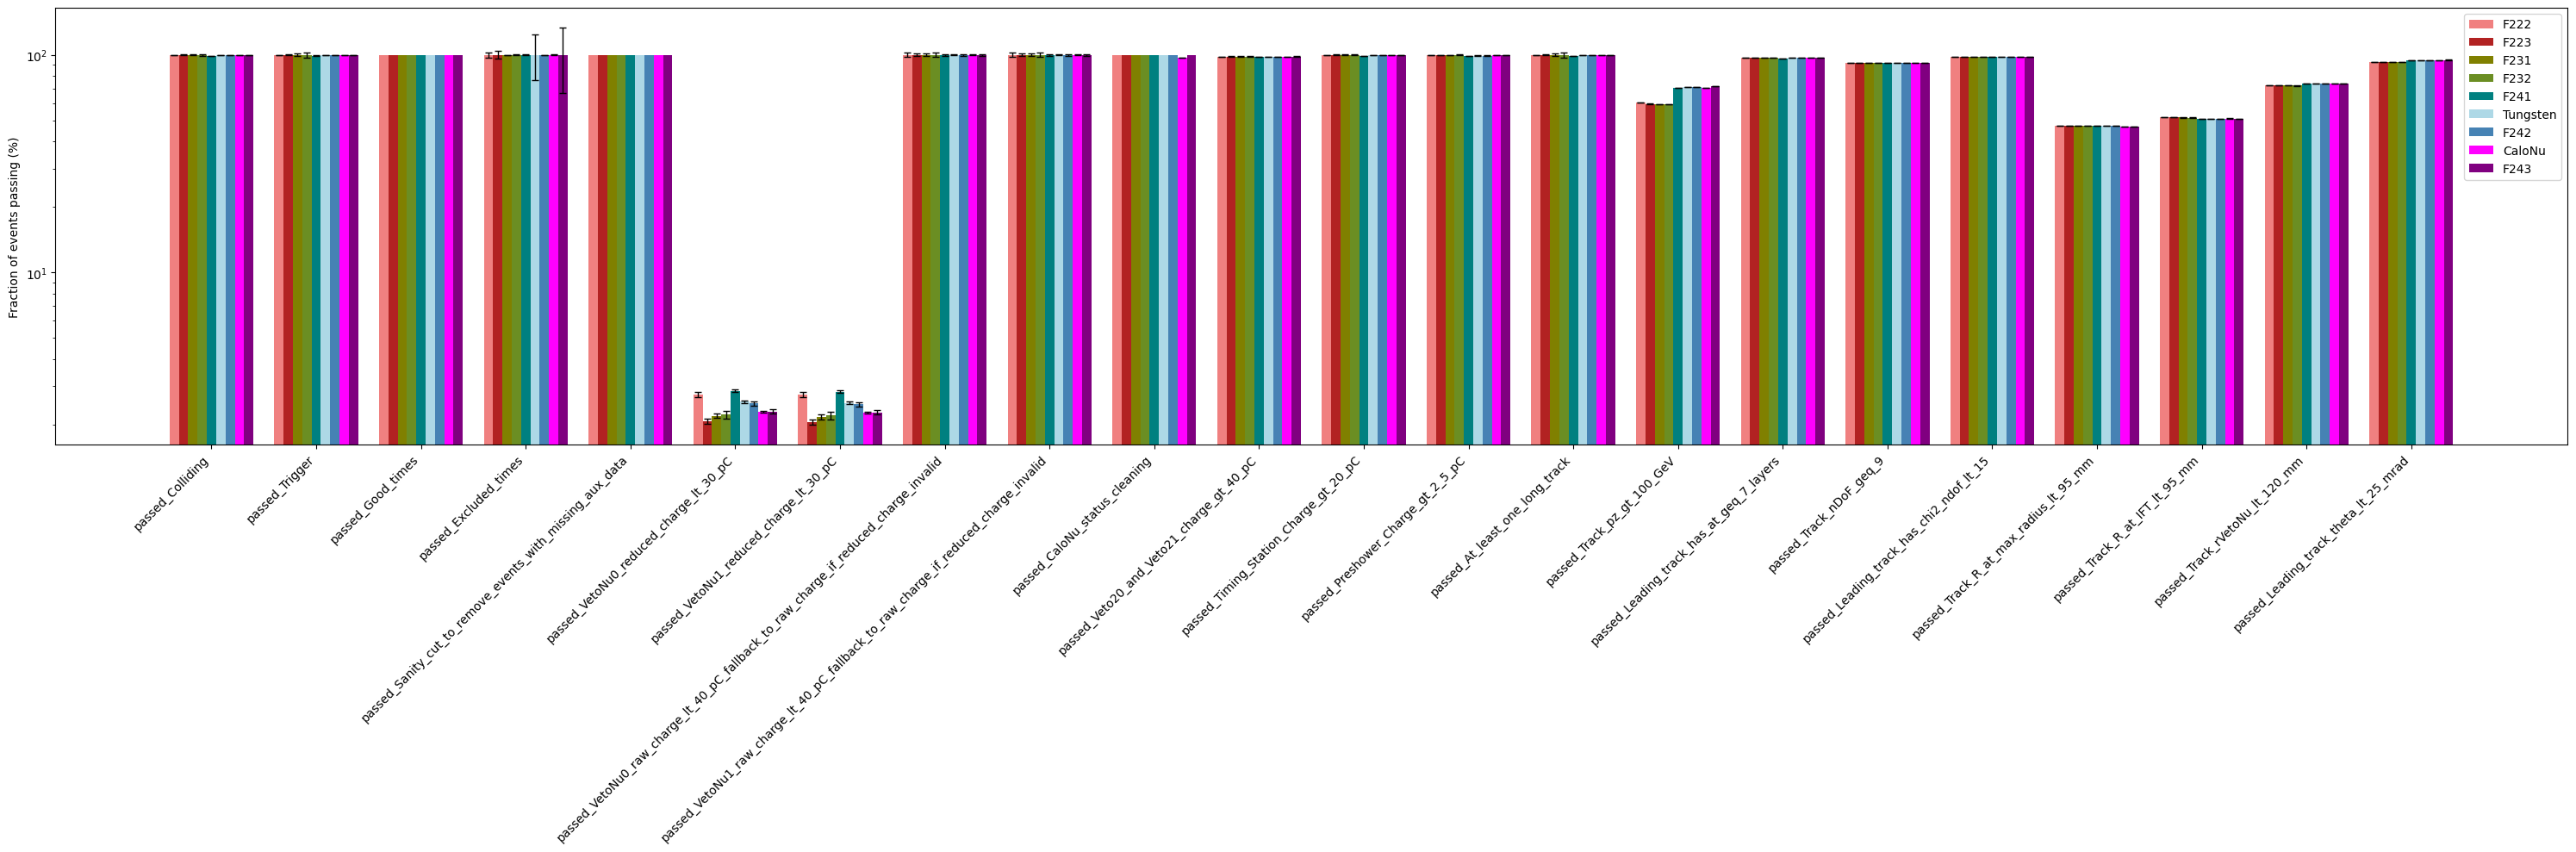

In [30]:
dfs = [pass_fail_counts_F222, pass_fail_counts_F223, pass_fail_counts_F231, pass_fail_counts_F232, pass_fail_counts_F241, pass_fail_counts_tungsten, pass_fail_counts_F242, pass_fail_counts_caloNu, pass_fail_counts_F243]
labels = ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"]

fig, ax = plt.subplots(figsize=(30, 10))

n = len(dfs)
x = np.arange(len(dfs[0]))
total_width = 0.8           # Total width occupied by all bars
bar_width = total_width / n

for i, (df, label) in enumerate(zip(dfs, labels)):

    n_pass = df["pass"]
    n_fail = df["fail"]
    n_tot = n_pass + n_fail
    
    offset = (i - (n - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        df["pass"] / (df["pass"] + df["fail"]) * 100,
        width=bar_width,
        label=label,
        color=colours[i]
    )
    ax.errorbar(
        x + offset,
        df["pass"] / (df["pass"] + df["fail"]) * 100,
        yerr=np.sqrt(1/df["pass"] + 1/df["fail"]) * 100,
        fmt='none',
        ecolor='black',
        capsize=3,
        elinewidth=1,
        label=None
    )

ax.set_xticks(x)
ax.set_xticklabels(dfs[0].index, rotation=45, ha="right")
ax.legend()
ax.set_ylabel("Fraction of events passing (%)")
ax.set_yscale("log")
plt.tight_layout()
plt.savefig("cutflow_pass_comparison.png", dpi=300)
plt.show()

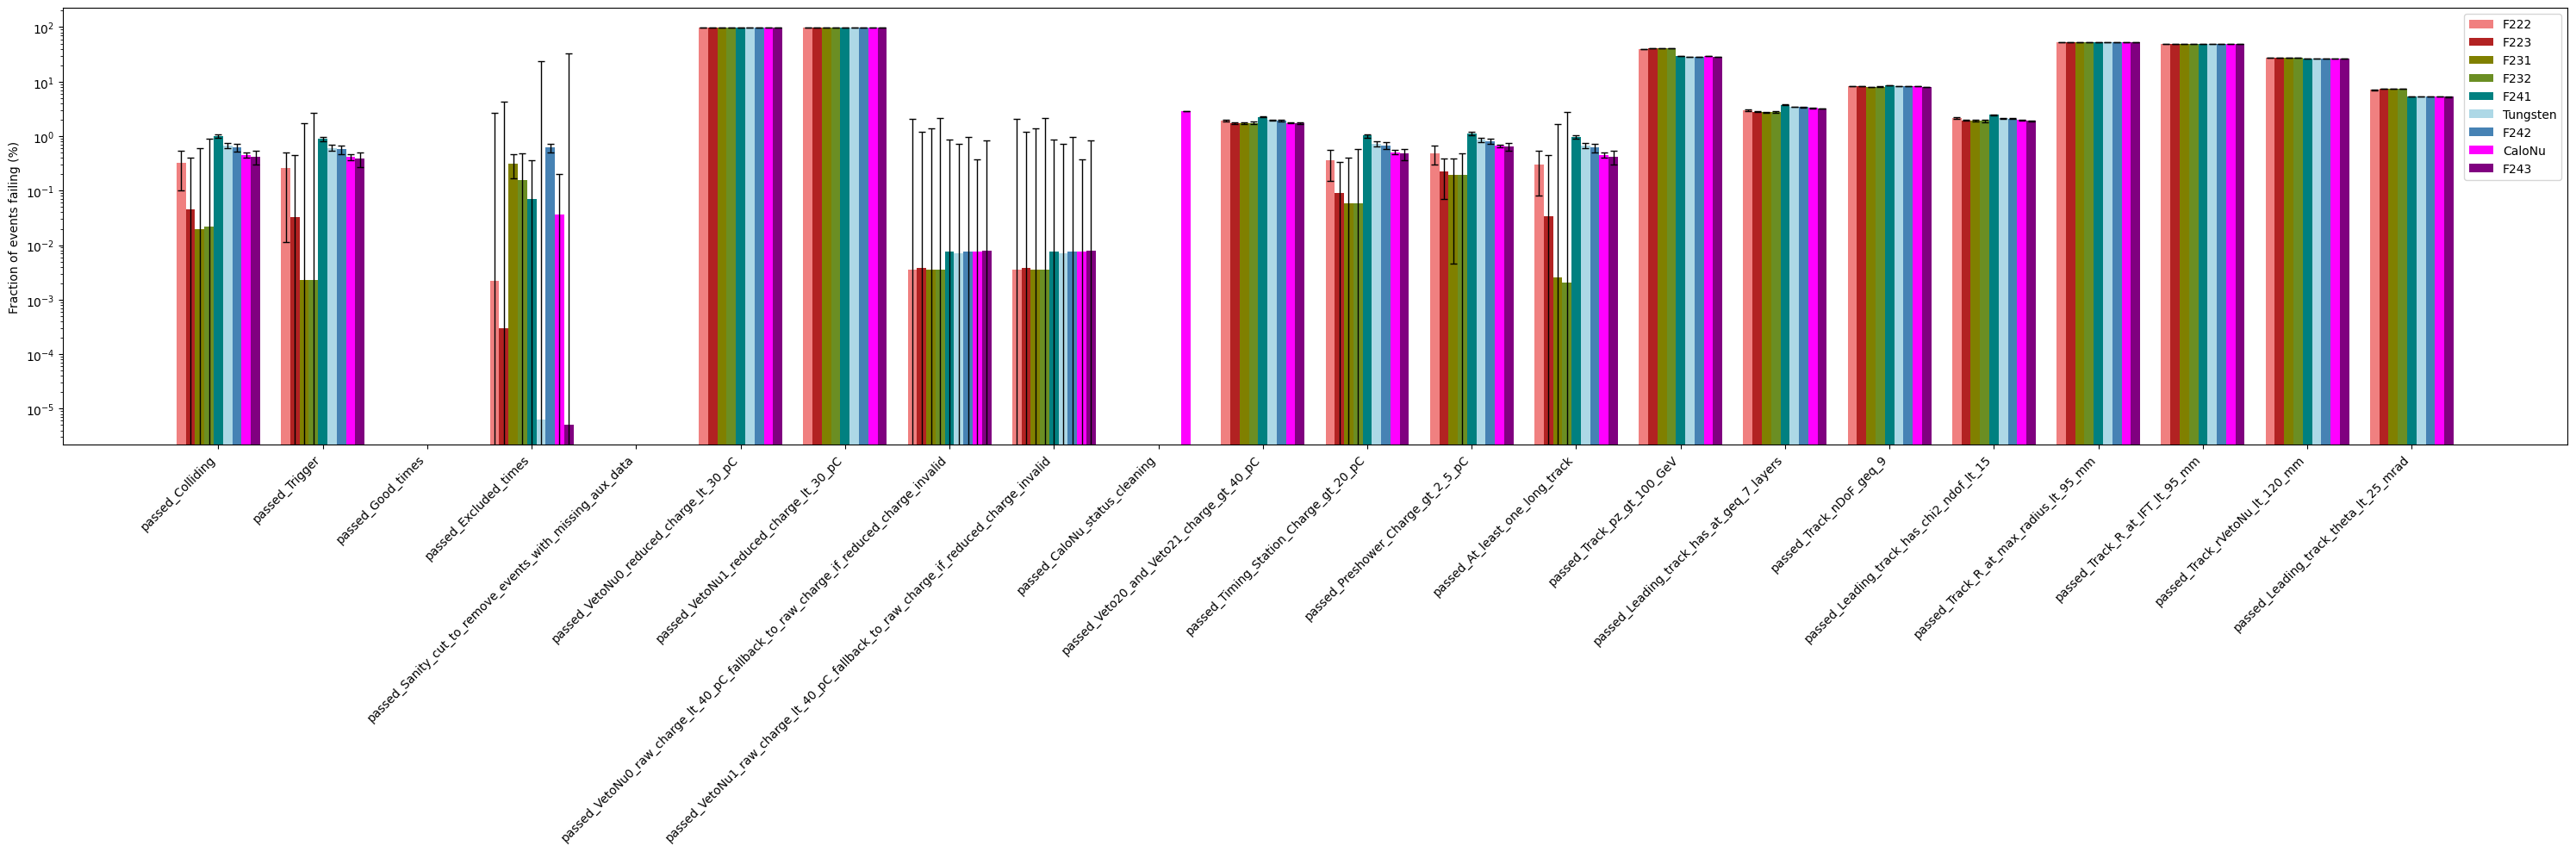

In [31]:
dfs = [pass_fail_counts_F222, pass_fail_counts_F223, pass_fail_counts_F231, pass_fail_counts_F232, pass_fail_counts_F241, pass_fail_counts_tungsten, pass_fail_counts_F242, pass_fail_counts_caloNu, pass_fail_counts_F243]
labels = ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"]

fig, ax = plt.subplots(figsize=(30, 10))

n = len(dfs)
x = np.arange(len(dfs[0]))
total_width = 0.8           # Total width occupied by all bars
bar_width = total_width / n

for i, (df, label) in enumerate(zip(dfs, labels)):

    n_pass = df["pass"]
    n_fail = df["fail"]
    n_tot = n_pass + n_fail
    
    offset = (i - (n - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        df["fail"] / (df["pass"] + df["fail"]) * 100,
        width=bar_width,
        label=label,
        color=colours[i]
    )
    ax.errorbar(
        x + offset,
        df["fail"] / (df["pass"] + df["fail"]) * 100,
        yerr=np.sqrt(1/df["pass"] + 1/df["fail"]) * 100,
        fmt='none',
        ecolor='black',
        capsize=3,
        elinewidth=1,
        label=None
    )

ax.set_xticks(x)
ax.set_xticklabels(dfs[0].index, rotation=45, ha="right")
ax.legend()
ax.set_ylabel("Fraction of events failing (%)")
ax.set_yscale("log")
# ax.set_ylim(1e-12, 1e3)
plt.savefig("cutflow_fail_comparison_log.png", dpi=300)
plt.tight_layout()
plt.show()

Trigger:
- `0x8`: [8] Second VetoLayer OR CaloNuBottom 
- `0x10`: [16] TimingLayerBottom
- `0x20`: [32] TimingLayerTop
- `0x40`: [64] PreshowerLayer